In [15]:
import struct
from os import path
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import PIL.Image as Image
import numpy as np
import torch.optim as optim
import torchinfo
import matplotlib.colors as mcolors
from jinja2.nodes import Tuple
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


#### Dataset preparation, loading and visualization



##### Dataset class for preloading and resizing data
For optimization, we will preload and resize all images into RAM. The structure is image pairs and corresponding optical flow file. We should split to train and val images

Implementing additional functions for loading images and flow files

*read_flo_file(FlyingChairsData)*

Implementation of loader for .flo binary format. For .flo format is important to check the 'magic number' (202021,25). So the .flo format is a sequence of raw bytes with a fixed structure

[4 bytes for magic number(float)] [4 bytes for width(int)] [4 bytes for height(int)] [rest is flow data(float)]

for every pixel there are 2 values u and v (height and width)

In [17]:
class FlyingChairsPreloadedDataset(Dataset):
    def __init__(self, subset, root='./FlyingChairsData',
                 split_file='./FlyingChairs_train_val.txt', resize=(256, 256), preloading_device='cpu'):
        self.root = Path(root)
        self.resize = resize
        self.preloading_device = preloading_device
        self.pairs = []

        all_flo_files = sorted(self.root.rglob('*_flow.flo'))  # recursively find all flo files
        all_ids = [int(file.stem.split('_')[0]) for file in all_flo_files]

        if subset in ('train', 'val'):
            with open(split_file, 'r') as file:
                labels = [int(line.strip()) for line in file.readlines()]
            target = 1 if subset == 'train' else 2
            ids = [datasetId for datasetId, label in zip(all_ids, labels) if label == target]
        else:
            raise ValueError('subset must be either train or val')

        print(f'[{subset}] Preloading {len(ids)} samples into RAM...')

        for i, datasetId in enumerate(ids):
            image1 = self.load_image(self.root / f'{datasetId:05d}_img1.ppm')  #
            image2 = self.load_image(self.root / f'{datasetId:05d}_img2.ppm')
            flow = self.read_flo_file(self.root / f'{datasetId:05d}_flow.flo')

            image1, image2, flow = self.resize_data(image1, image2, flow)

            image1 = self.to_tensor(image1)
            image2 = self.to_tensor(image2)
            flow = self.to_tensor(flow)

            self.pairs.append((image1, image2, flow))

            if (i + 1) % 1000 == 0:
                print(f'  {i + 1}/{len(ids)} loaded...')

        print(f'[{subset}] Done.')

    def read_flo_file(self, filepath: Path = "FlyingChairsData") -> np.ndarray:
        with open(filepath, 'rb') as file:  # open BINARY READING
            magic_num = struct.unpack('f', file.read(4))[
                0]  # struct returns a tuple and [0] extracts the actual num we want
            if magic_num != 202021.25:
                raise ValueError('Magic number mismatch you are not working with .flo file')
            width = struct.unpack('i', file.read(4))[0]
            height = struct.unpack('i', file.read(4))[0]
            flow = np.frombuffer(file.read(), dtype=np.float32).reshape((height, width, 2))

        return flow

    def load_image(self, path) -> np.ndarray:
        image = Image.open(path).convert('RGB')
        return np.array(image, dtype=np.float32) / 255.0

    def resize_data(self, image1, image2, flow):
        new_W, new_H = self.resize
        old_H, old_W = image1.shape[:2]

        # scaling the image
        image1 = cv2.resize(image1, (new_W, new_H))
        image2 = cv2.resize(image2, (new_W, new_H))
        flow = cv2.resize(flow, (new_W, new_H))

        # adapting the motion/ vector to match the smaller picture
        flow[..., 0] *= new_W / old_W
        flow[..., 1] *= new_H / old_H

        return image1, image2, flow

    def to_tensor(self, x):
        return torch.from_numpy(x.transpose(2, 0, 1)).to(self.preloading_device)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]


#### Helper functions for visualization

Firstly we convert the flow fields to polar coordinates. With using of magnitude(sqrt(v^2 + u^2)) and angle(atg(v,u) we can see how fast has something moved and which direction did it take.

flow[..., 0] u - x direction

flow[..., 1] v - y direction

Then we need a function that will take the magnitude(how fast moved) and angle(the direction of movement) and map to HSV or hue, saturation and value.

Hue shows us the direction of the  movement (one color will be for left, other for right..) - 1st Channel

Saturation will show us how strong was the movement (strong color is high motion) - 2nd channel

Value will be fixed and will help us show cleaner image (near max value) - 3rd channel

HSV[y, x] = [direction, speed, brightness]

In [18]:
def convert_flow_to_polar(flow: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # u = flow[..., 0]
    # v = flow[..., 1] todo this makes error
    u = flow[0]
    v = flow[1]

    magnitude = np.sqrt(u ** 2 + v ** 2)
    angle = np.arctan2(v, u)

    return magnitude, angle


def map_to_hsv(magnitude, angle, value=0.999) -> np.ndarray:
    hue = (angle + np.pi) / (2 * np.pi)  # hue is a color wheel from 0 to 365
    saturation = magnitude / (magnitude.max() + 1e-5)

    H, W = magnitude.shape

    hsv = np.zeros((H, W, 3), dtype=np.float32)
    hsv[..., 0] = hue
    hsv[..., 1] = saturation
    hsv[..., 2] = value

    rgb = mcolors.hsv_to_rgb(hsv)

    return rgb


def visualize_flow(image1, image2, flow):
    magnitude, angle = convert_flow_to_polar(flow.numpy())
    flow_rgb = map_to_hsv(magnitude, angle)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].imshow(image1.numpy().transpose(1, 2, 0))
    axes[0].set_title('Frame 1')

    axes[1].imshow(image2.numpy().transpose(1, 2, 0))
    axes[1].set_title('Frame 2')

    axes[2].imshow(flow_rgb)
    axes[2].set_title('Optical Flow (HSV)')

    plt.tight_layout()
    plt.show()


def visualize_flow_multiscale(flow, num_levels=6):
    flow_levels = []
    current_flow = flow.unsqueeze(0).float()  # (1, 2, H, W)

    for i in range(num_levels):
        H, W = current_flow.shape[2], current_flow.shape[3]
        flow_levels.append(current_flow[0])  # (2, H, W)

        if i < num_levels - 1:
            new_H, new_W = H // 2, W // 2
            current_flow = torch.nn.functional.interpolate(
                current_flow, size=(new_H, new_W), mode='bilinear', align_corners=False
            )
            current_flow[:, 0] *= new_W / W
            current_flow[:, 1] *= new_H / H

    fig, axes = plt.subplots(1, num_levels, figsize=(4 * num_levels, 4))

    for i, f in enumerate(flow_levels):
        H, W = f.shape[1], f.shape[2]
        magnitude, angle = convert_flow_to_polar(f.numpy())
        flow_rgb = map_to_hsv(magnitude, angle)

        axes[i].imshow(flow_rgb, interpolation='nearest')
        axes[i].set_title(f'Flow ({H}, {W})')
        axes[i].set_axis_off()

    plt.tight_layout()
    plt.show()


[train] Preloading 22232 samples into RAM...
  1000/22232 loaded...
  2000/22232 loaded...
  3000/22232 loaded...
  4000/22232 loaded...
  5000/22232 loaded...
  6000/22232 loaded...
  7000/22232 loaded...
  8000/22232 loaded...
  9000/22232 loaded...
  10000/22232 loaded...
  11000/22232 loaded...
  12000/22232 loaded...
  13000/22232 loaded...
  14000/22232 loaded...
  15000/22232 loaded...
  16000/22232 loaded...
  17000/22232 loaded...
  18000/22232 loaded...
  19000/22232 loaded...
  20000/22232 loaded...
  21000/22232 loaded...
  22000/22232 loaded...
[train] Done.
[val] Preloading 640 samples into RAM...
[val] Done.
torch.Size([8, 3, 256, 256])
torch.Size([8, 3, 256, 256])
torch.Size([8, 2, 256, 256])


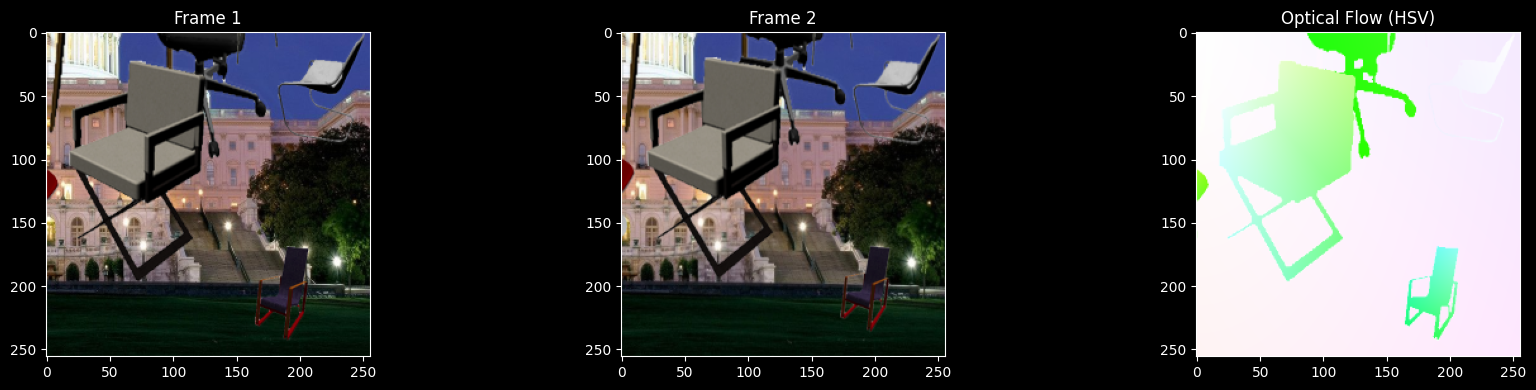

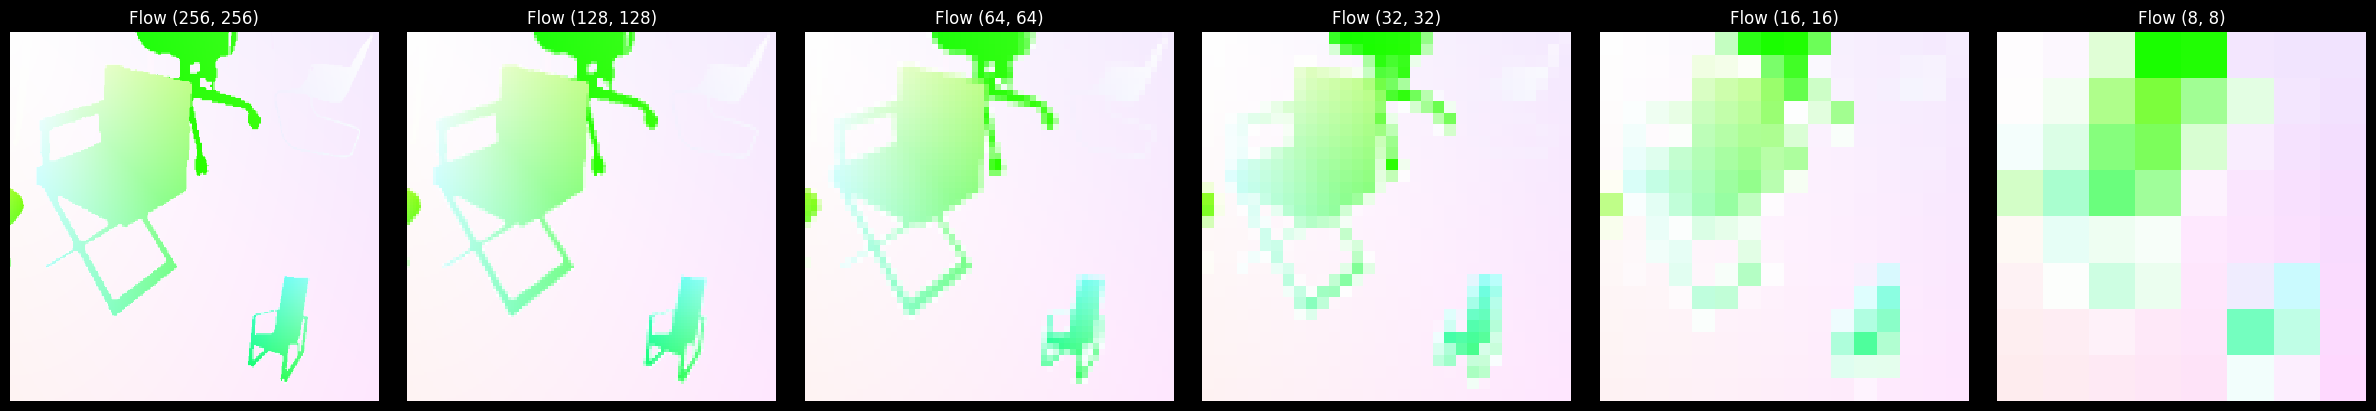

In [19]:
train_set = FlyingChairsPreloadedDataset(subset='train')
val_set = FlyingChairsPreloadedDataset(subset='val')

train_loader = DataLoader(train_set, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

img1_batch, img2_batch, flow_batch = next(iter(train_loader))
print(img1_batch.shape)
print(img2_batch.shape)
print(flow_batch.shape)

sample_image1 = img1_batch[0]
sample_image2 = img2_batch[0]
sample_flow = flow_batch[0]

visualize_flow(sample_image1, sample_image2, sample_flow)
visualize_flow_multiscale(sample_flow)

#### FlowNetSimple Neural Network

The neural network is built of encoder and decoder and it is very similar to an U network.


##### Encoder

Encoder gets an image that is make of 2 RGB images concatenated alog the channels axis (it has 6 channels). The encoder is build of  3 DownBlocks (Conv - BatchNorm - ReLu - Conv - BatchNorm - ReLu - MaxPool). Then follows a block in the bottleneck that has Conv - BatchNorm - ReLu - Conv - BatchNorm - ReLu. This block repeats 2 in the bottleneck.


In [20]:
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()

        self.convolution_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size // 2),  ## todo //2
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),  # saves memory as no extra tensor is allocated
            nn.Conv2d(out_channels, out_channels, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.convolution_block(x)
        out = self.pool(skip)
        return out, skip

In [21]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.downBlock1 = DownBlock(in_channels=6, out_channels=16, kernel_size=7)  # todo  7
        self.downBlock2 = DownBlock(in_channels=16, out_channels=32, kernel_size=5)
        self.downBlock3 = DownBlock(in_channels=32, out_channels=64, kernel_size=3)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        out1, skip1 = self.downBlock1(x)
        out2, skip2 = self.downBlock2(out1)
        out3, skip3 = self.downBlock3(out2)

        bottleneck = self.bottleneck(out3)

        return bottleneck, skip1, skip2, skip3

##### Decoder

Decoder takes the skip connection from before each MaxPool in the Encoder (skip connecting are 'saving' the details from the image). We can say that it is build from 2 part and the bottleneck has 2 outputs. So in the decoder with ConvTranspose we concatenate with matching encoder skip. The 'other' output at each decoder level adds a prediction using ConvTranspose and concatenate it to a next decoder level


The naming rule:

deconvN — feature upsampler going to level N (ConvTranspose on multi-channel features)
predict_flowN — the 1×1 conv that produces the flow prediction at level N
up_flowN — upsampler that lifts that flow prediction one level higher
flowN — the actual flow tensor at level N (output)
flowN_up — that flow tensor after being upsampled
feat_N — feature concat (skip + upsampled features) at level N, fed to the next deconv
concatN — full concat (feat + previous flow) at level N, fed to predict_flowN

In [22]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        # ----- Bottleneck-level prediction (32×32) -----
        self.predict_flow4 = nn.Conv2d(in_channels=128, out_channels=2, kernel_size=1)
        self.up_flow4 = nn.ConvTranspose2d(in_channels=2, out_channels=2, kernel_size=2, stride=2)

        self.deconv3 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
        self.predict_flow3 = nn.Conv2d(in_channels=130, out_channels=2, kernel_size=1)  # 64 + 64 + 2
        self.up_flow3 = nn.ConvTranspose2d(in_channels=2, out_channels=2, kernel_size=2, stride=2)

        self.deconv2 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=2, stride=2)
        self.predict_flow2 = nn.Conv2d(in_channels=66, out_channels=2, kernel_size=1)  # 32 + 32 + 2
        self.up_flow2 = nn.ConvTranspose2d(in_channels=2, out_channels=2, kernel_size=2, stride=2)

        self.deconv1 = nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=2, stride=2)
        self.predict_flow1 = nn.Conv2d(in_channels=34, out_channels=2, kernel_size=1)  # 16 + 16 + 2

    def forward(self, bottleneck, skip1, skip2, skip3):
        # ----- Bottleneck prediction (32x32) -----
        flow4 = self.predict_flow4(bottleneck)              # (B,   2, 32,  32)
        flow4_up = self.up_flow4(flow4)                     # (B,   2, 64,  64)

        # ----- Level 3 (64x64) -----
        up_feat3 = self.deconv3(bottleneck)                 # (B,  64, 64,  64)   128 -> 64
        feat3   = torch.cat([up_feat3, skip3], dim=1)       # (B, 128, 64,  64)
        concat3 = torch.cat([feat3, flow4_up], dim=1)       # (B, 130, 64,  64)
        flow3   = self.predict_flow3(concat3)               # (B,   2, 64,  64)
        flow3_up = self.up_flow3(flow3)                     # (B,   2, 128, 128)

        # ----- Level 2 (128x128) -----
        up_feat2 = self.deconv2(up_feat3)                   # (B,  32, 128, 128)  64 -> 32   ← was self.deconv2(feat3)
        feat2   = torch.cat([up_feat2, skip2], dim=1)       # (B,  64, 128, 128)
        concat2 = torch.cat([feat2, flow3_up], dim=1)       # (B,  66, 128, 128)
        flow2   = self.predict_flow2(concat2)               # (B,   2, 128, 128)
        flow2_up = self.up_flow2(flow2)                     # (B,   2, 256, 256)

        # ----- Level 1 (256x256) -----
        up_feat1 = self.deconv1(up_feat2)                   # (B,  16, 256, 256)  32 -> 16   ← was self.deconv1(feat2)
        feat1   = torch.cat([up_feat1, skip1], dim=1)       # (B,  32, 256, 256)
        concat1 = torch.cat([feat1, flow2_up], dim=1)       # (B,  34, 256, 256)
        flow1   = self.predict_flow1(concat1)               # (B,   2, 256, 256)

        return flow1, flow2, flow3, flow4

##### FlowNetSimple Neural Network


In [23]:
class FlowNetSimple(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, image1, image2):
        x = torch.cat([image1, image2], dim=1)
        bottleneck, skip1, skip2, skip3 = self.encoder(x)
        flow1, flow2, flow3, flow4 = self.decoder(bottleneck, skip1, skip2, skip3)
        return flow1, flow2, flow3, flow4

In [24]:
model = FlowNetSimple().to(device)
torchinfo.summary(
    model,
    input_size=[(1, 3, 256, 256), (1, 3, 256, 256)],  # one per forward arg
    device=device,
    depth=4,                # how deep to expand nested modules
    col_names=("input_size", "output_size", "num_params", "mult_adds"),
)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler("cuda")

#### Train the model with last or multiple outputs


##### Train and validate with last output only + loss visualization

Using EPE (endpoint error = Euclidean distance between ground truth and predicted flow) loss. The distance is averaged over all pixels. We supervise only the highest resolution decoder output.

In [25]:
def epe_last_output_loss(predicted, target) -> torch.Tensor:
    return torch.mean(torch.sqrt(((predicted - target) ** 2).sum(dim=1)))

In [26]:
def train_last_output(model, loader, optimizer, device, current_step, max_steps) -> tuple[float, int]:
    model.train()
    total_loss = 0.0
    steps_done = 0

    for i, (image1, image2, flow) in enumerate(loader):
        if current_step + steps_done >= max_steps:
            break

        image1 = image1.to(device, non_blocking=True)
        image2 = image2.to(device, non_blocking=True)
        flow = flow.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=device.type == "cuda", dtype=torch.float16):
            flow1, flow2, flow3, flow4 = model(image1, image2)
            loss = epe_last_output_loss(flow1, flow)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        steps_done += 1

        # if steps_done % 100 == 0:
        #     print(f'\r  ...epoch in progress, batch {steps_done}, last loss {loss.item():.4f}', end='', flush=True)

    return total_loss / max(steps_done, 1), steps_done

In [27]:
def validate_last_output(model, loader, device) -> float:
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for i, (image1, image2, flow) in enumerate(loader):
            image1 = image1.to(device, non_blocking=True)
            image2 = image2.to(device, non_blocking=True)
            flow = flow.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=device.type == "cuda", dtype=torch.float16):
                flow1, flow2, flow3, flow4 = model(image1, image2)
                loss = epe_last_output_loss(flow1, flow)

            total_loss += loss.item()

    return total_loss / len(loader)

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model_single = FlowNetSimple().to(device)
optimizer = optim.Adam(model_single.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler("cuda")

train_losses_last_output = []
val_losses_last_output = []

step = 0
max_steps = 500000

for epoch in range(1, 10000):
    train_loss, steps_done = train_last_output(model_single, train_loader, optimizer, device, step, max_steps)
    val_loss = validate_last_output(model_single, val_loader, device)

    train_losses_last_output.append(train_loss)
    val_losses_last_output.append(val_loss)

    step += steps_done

    print(f'[Epoch {epoch:>3}] Step {step:>6}/{max_steps} | Train EPE: {train_loss:.4f} | Val EPE: {val_loss:.4f}')

    if step % 10000 < len(train_loader):  # saving model everu 10 000
        torch.save({
            'step': step,
            'model_state_dict': model_single.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses_last_output,
            'val_losses': val_losses_last_output,
        }, f'flownet_single_step{step}.pth')
        print(f'           checkpoint saved at step {step}')

    if step >= max_steps:  # final save
        torch.save({
            'step': step,
            'model_state_dict': model_single.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses_last_output,
            'val_losses': val_losses_last_output,
        }, 'flownet_single_final.pth')
        print('           final last-output model saved')
        break

Using device: cuda
  Step 1000/500000 | Loss: 4.2353
  Step 2000/500000 | Loss: 5.9394
Step 2779/500000 | Train EPE: 5.8511 | Val EPE: 5.6646
  Step 3000/500000 | Loss: 3.2834
  Step 4000/500000 | Loss: 5.1515
  Step 5000/500000 | Loss: 3.7849
Step 5558/500000 | Train EPE: 5.0618 | Val EPE: 4.5591
  Step 6000/500000 | Loss: 4.3499
  Step 7000/500000 | Loss: 6.9825
  Step 8000/500000 | Loss: 2.7708
Step 8337/500000 | Train EPE: 4.6937 | Val EPE: 4.3821
  Step 9000/500000 | Loss: 3.2180
  Step 10000/500000 | Loss: 6.1518
  Step 11000/500000 | Loss: 3.0811
Step 11116/500000 | Train EPE: 4.5125 | Val EPE: 4.4058
  Checkpoint saved at step 11116
  Step 12000/500000 | Loss: 2.2503
  Step 13000/500000 | Loss: 2.5119
Step 13895/500000 | Train EPE: 4.3681 | Val EPE: 4.1008
  Step 14000/500000 | Loss: 2.7318
  Step 15000/500000 | Loss: 4.3846
  Step 16000/500000 | Loss: 2.0541
Step 16674/500000 | Train EPE: 4.2368 | Val EPE: 4.1436
  Step 17000/500000 | Loss: 3.8940
  Step 18000/500000 | Loss: 3

In [29]:
def plot_train_val_loss(is_last_output=False):
    plt.figure(figsize=(8, 4))

    if is_last_output:
        plt.plot(train_losses_last_output, label='Train EPE')
        plt.plot(val_losses_last_output,   label='Val EPE')
        plt.title('Single Output - Training & Validation Loss')
        out_path = 'loss_single_output.png'
    else:
        plt.plot(train_losses_multi_output, label='Train EPE')
        plt.plot(val_losses_multi_output,   label='Val EPE')
        plt.title('Multi Output - Training & Validation Loss')
        out_path = 'loss_multi_outputs.png'

    plt.xlabel('Epoch')
    plt.ylabel('EPE Loss')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.show()

plot_train_val_loss(True)

##### Train with last output only

Using EPE (endpoint error = Euclidean distance between ground truth and predicted flow) loss. EPE is computed at every decoder prediction head  at all resolution levels, and sum/avg them

In [30]:
def epe_multi_output_loss(predictions, target) -> torch.Tensor:
    H_target, W_target = target.shape[-2:]

    total_loss = torch.tensor(0.0, device=target.device)

    for predicted in predictions:
        H_predicted, W_predicted = predicted.shape[-2:]
        target_s = nn.functional.interpolate(
            target, size=(H_predicted, W_predicted),
            mode='bilinear', align_corners=False
        ).clone()  # resizing ground truth flow map to match the spatial dimensions of model's prediction
        target_s[:, 0] *= W_predicted / W_target
        target_s[:, 1] *= H_predicted / H_target

        epe = torch.mean(torch.sqrt(((predicted - target_s) ** 2).sum(dim=1)))
        total_loss += epe

    return total_loss / len(predictions)

In [31]:
def train_multi_outputs(model, loader, optimizer, device, current_step, max_steps) -> tuple[float, int]:
    model.train()
    total_loss = 0.0
    steps_done = 0

    for i, (image1, image2, flow) in enumerate(loader):
        if current_step + steps_done >= max_steps:
            break

        image1 = image1.to(device, non_blocking=True)
        image2 = image2.to(device, non_blocking=True)
        flow = flow.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=device.type == "cuda", dtype=torch.float16):
            predictions = model(image1, image2)
            loss = epe_multi_output_loss(predictions, flow)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        steps_done += 1

        # if steps_done % 100 == 0:
        #     print(f'\r  ...epoch in progress, batch {steps_done}, last loss {loss.item():.4f}', end='', flush=True)

    return total_loss / max(steps_done, 1), steps_done

In [32]:
def validate_multi_output(model, loader, device) -> float:
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for i, (image1, image2, flow) in enumerate(loader):
            image1 = image1.to(device, non_blocking=True)
            image2 = image2.to(device, non_blocking=True)
            flow = flow.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=device.type == "cuda", dtype=torch.float16):
                predictions = model(image1, image2)
                loss = epe_multi_output_loss(predictions, flow)

            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model_multi = FlowNetSimple().to(device)
optimizer = optim.Adam(model_multi.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler("cuda")

train_losses_multi_output = []
val_losses_multi_output = []

step = 0
max_steps = 500000

for epoch in range(1, 10000):
    train_loss, steps_done = train_multi_outputs(model_multi, train_loader, optimizer, device, step, max_steps)
    val_loss = validate_multi_output(model_multi, val_loader, device)

    train_losses_multi_output.append(train_loss)
    val_losses_multi_output.append(val_loss)

    step += steps_done

    print(f'[Epoch {epoch:>3}] Step {step:>6}/{max_steps} | Train EPE: {train_loss:.4f} | Val EPE: {val_loss:.4f}')

    if step % 10000 < len(train_loader):  # saving model everu 10 000
        torch.save({
            'step': step,
            'model_state_dict': model_multi.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses_multi_output,
            'val_losses': val_losses_multi_output,
        }, f'flownet_multi_step{step}.pth')
        print(f'           checkpoint saved at step {step}')

    if step >= max_steps:  # final save
        torch.save({
            'step': step,
            'model_state_dict': model_multi.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses_multi_output,
            'val_losses': val_losses_multi_output,
        }, 'flownet_multi_final.pth')
        print('           final multi-output model saved')
        break

Using device: cuda
  Step 1000/500000 | Loss: 1.9351
  Step 2000/500000 | Loss: 2.4967
Step 2779/500000 | Train EPE: 2.6260 | Val EPE: 2.2611
  Step 3000/500000 | Loss: 1.3281
  Step 4000/500000 | Loss: 1.3497
  Step 5000/500000 | Loss: 1.6111
Step 5558/500000 | Train EPE: 2.2901 | Val EPE: 2.1091
  Step 6000/500000 | Loss: 0.8217
  Step 7000/500000 | Loss: 1.9177
  Step 8000/500000 | Loss: 5.1847
Step 8337/500000 | Train EPE: 2.1617 | Val EPE: 2.0016
  Step 9000/500000 | Loss: 2.2289
  Step 10000/500000 | Loss: 1.6476
  Step 11000/500000 | Loss: 1.7370
Step 11116/500000 | Train EPE: 2.0794 | Val EPE: 1.9707
  Checkpoint saved at step 11116
  Step 12000/500000 | Loss: 2.1654
  Step 13000/500000 | Loss: 1.6227
Step 13895/500000 | Train EPE: 2.0122 | Val EPE: 1.9382
  Step 14000/500000 | Loss: 2.5180
  Step 15000/500000 | Loss: 1.8109
  Step 16000/500000 | Loss: 2.9722
Step 16674/500000 | Train EPE: 1.9608 | Val EPE: 1.8530
  Step 17000/500000 | Loss: 3.0817
  Step 18000/500000 | Loss: 1

In [ ]:
plot_train_val_loss(False)

#### Evaluations

##### On MPI Sintel dataset

In [ ]:
class SintelDataset(Dataset):
    def __init__(self, root='./MPI-Sintel-complete', pass_type='clean', resize=(256, 256)):
        self.root = Path(root)
        self.resize = resize
        self.pairs = []

        flow_root = self.root / 'training' / 'flow'  # todo
        image_root = self.root / 'training' / pass_type

        for scene_dir in sorted(p for p in flow_root.iterdir() if p.is_dir()):
            scene = scene_dir.name
            for flo_file in sorted(scene_dir.glob('*.flo')):
                fnum = int(flo_file.stem.split('_')[-1])
                image1 = image_root / scene / f'frame_{fnum:04d}.png'
                image2 = image_root / scene / f'frame_{fnum + 1:04d}.png'
                if image1.exists() and image2.exists():
                    self.pairs.append((image1, image2, flo_file))

        print(f'[Sintel/{pass_type}] Found {len(self.pairs)} pairs')

    def read_flo_file(self, filepath: Path) -> np.ndarray:
        with open(filepath, 'rb') as file:
            magic_num = struct.unpack('f', file.read(4))[0]
            if magic_num != 202021.25:
                raise ValueError('Magic number mismatch — not a valid .flo file')
            width = struct.unpack('i', file.read(4))[0]
            height = struct.unpack('i', file.read(4))[0]
            flow = np.frombuffer(file.read(), dtype=np.float32).reshape((height, width, 2))
        return flow

    def load_image(self, path) -> np.ndarray:
        return np.array(Image.open(path).convert('RGB'), dtype=np.float32) / 255.0

    def resize_data(self, image1, image2, flow):
        new_W, new_H = self.resize
        old_H, old_W = image1.shape[:2]

        image1 = cv2.resize(image1, (new_W, new_H))
        image2 = cv2.resize(image2, (new_W, new_H))
        flow = cv2.resize(flow, (new_W, new_H))

        flow[..., 0] *= new_W / old_W
        flow[..., 1] *= new_H / old_H

        return image1, image2, flow

    def to_tensor(self, x):
        return torch.from_numpy(x.transpose(2, 0, 1))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, flo_path = self.pairs[idx]

        image1 = self.load_image(img1_path)
        image2 = self.load_image(img2_path)
        flow = self.read_flo_file(flo_path)

        image1, image2, flow = self.resize_data(image1, image2, flow)

        return self.to_tensor(image1), self.to_tensor(image2), self.to_tensor(flow)

In [ ]:
sintel_dataset = SintelDataset()
sintel_loader = DataLoader(sintel_dataset, batch_size=8, shuffle=False, num_workers=4)

img1_batch, img2_batch, flow_batch = next(iter(sintel_loader))
print(img1_batch.shape)
print(img2_batch.shape)
print(flow_batch.shape)

sample_image1 = img1_batch[0]
sample_image2 = img2_batch[0]
sample_flow = flow_batch[0]

visualize_flow(sample_image1, sample_image2, sample_flow)
visualize_flow_multiscale(sample_flow)

In [ ]:
def evaluate_on_sintel(model, sintel_loader, device) -> float:
    model.eval()
    total_epe = 0.0

    for image1, image2, flow in sintel_loader:
        image1 = image1.to(device, non_blocking=True)
        image2 = image2.to(device, non_blocking=True)
        flow = flow.to(device, non_blocking=True)

        flow1, _, _, _ = model(image1, image2)  # only highest resolution output
        epe = epe_last_output_loss(flow1, flow)
        total_epe += epe.item()

    return total_epe / len(sintel_loader)

In [ ]:
checkpoint_single = torch.load('flownet_single_final.pth', map_location=device)
model_single.load_state_dict(checkpoint_single['model_state_dict'])

checkpoint_multi = torch.load('flownet_multi_final.pth', map_location=device)
model_multi.load_state_dict(checkpoint_multi['model_state_dict'])

for pass_type in ('clean', 'final'):
    sintel_dataset = SintelDataset(pass_type=pass_type, resize=(256, 256))
    sintel_loader_eval = DataLoader(sintel_dataset, batch_size=8, shuffle=False, num_workers=4)
    epe_single = evaluate_on_sintel(model_single, sintel_loader_eval, device)
    epe_multi  = evaluate_on_sintel(model_multi,  sintel_loader_eval, device)

    print(f'[{pass_type}] single: {epe_single:.4f} px | multi: {epe_multi:.4f} px')

##### On Farneback baseline (OpenCV)

Tunning different parameters
pyr_scale — how much to shrink each pyramid level (0.5 = half size). Lower = captures larger motion but loses detail

levels — number of pyramid levels. More levels = handles faster motion

winsize — smoothing window size. Larger = smoother but blurs boundaries

iterations — iterations per pyramid level. More = more accurate but slower

poly_n — neighbourhood size for polynomial expansion (5 or 7). Larger = smoother

poly_sigma — gaussian sigma for polynomial expansion. Larger = smoother


In [ ]:
def farneback_flow(image1_uint8, image2_uint,  pyr_scale=0.5, levels=3, winsize=15,iterations=3, poly_n=5, poly_sigma=1.2)-> Tuple[float, float]:
    g1 = cv2.cvtColor(image1_uint8, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(image2_uint, cv2.COLOR_RGB2GRAY)
    flow = cv2.calcOpticalFlowFarneback(
        g1, g2, None,
        pyr_scale, levels, winsize, iterations, poly_n, poly_sigma, 0
    )
    return flow

def evaluate_farneback(loader, **fb_kwargs):
    epes = []
    for image1, image2, flow in loader:
        for b in range(image1.shape[0]):
            img1_np = (image1[b].numpy().transpose(1, 2, 0) * 255.0).astype(np.uint8)
            img2_np = (image2[b].numpy().transpose(1, 2, 0) * 255.0).astype(np.uint8)
            gt      = flow[b].numpy().transpose(1, 2, 0)

            pred = farneback_flow(img1_np, img2_np, **fb_kwargs)

            epe_map = np.sqrt(((pred - gt) ** 2).sum(axis=-1))
            epes.append(float(epe_map.mean()))

    epes = np.array(epes)
    return float(epes.mean()), float(epes.std()), epes

In [ ]:
configs = [
    dict(pyr_scale=0.5, levels=3, winsize=15, iterations=3, poly_n=5, poly_sigma=1.2),  # default
    dict(pyr_scale=0.5, levels=5, winsize=15, iterations=3, poly_n=5, poly_sigma=1.2),  # more levels
    dict(pyr_scale=0.5, levels=5, winsize=25, iterations=5, poly_n=7, poly_sigma=1.5),  # larger window
    dict(pyr_scale=0.5, levels=7, winsize=20, iterations=5, poly_n=7, poly_sigma=1.5),  # deep pyramid
]

print('=== Farneback parameter search ===')
best_mean  = float('inf')
best_params = None

for params in configs:
    mean_epe, std_epe, _ = evaluate_farneback(sintel_loader, **params)
    print(f'mean EPE: {mean_epe:.3f}  std: {std_epe:.3f}  | {params}')
    if mean_epe < best_mean:
        best_mean   = mean_epe
        best_params = params

print(f'\nBest config: {best_params}')
print(f'Best mean EPE: {best_mean:.3f}')

for pass_type in ('clean', 'final'):
    sintel_dataset     = SintelDataset(pass_type=pass_type, resize=(256, 256))
    sintel_loader_eval = DataLoader(sintel_dataset, batch_size=8, shuffle=False, num_workers=4)

    epe_single = evaluate_on_sintel(model_single, sintel_loader_eval, device)
    epe_multi  = evaluate_on_sintel(model_multi,  sintel_loader_eval, device)
    epe_fb, std_fb, _ = evaluate_farneback(sintel_loader_eval, **best_params)

    print(f'[{pass_type}] single: {epe_single:.4f} px | multi: {epe_multi:.4f} px | farneback: {epe_fb:.4f} px (std {std_fb:.3f})')

##### Own video

In [ ]:
def process_video(model, video_path, output_path, device, target_size=(256, 256)):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    ret, prev = cap.read()

    out_W, out_H = target_size
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (out_W * 2, out_H))

    model.eval()
    frame_idx = 0
    with torch.no_grad():
        while True:
            ret, curr = cap.read()
            if not ret:
                break

            image1_rgb = cv2.cvtColor(cv2.resize(prev, target_size), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.
            image2_rgb = cv2.cvtColor(cv2.resize(curr, target_size), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.

            t1 = torch.from_numpy(image1_rgb.transpose(2, 0, 1)).unsqueeze(0).to(device)
            t2 = torch.from_numpy(image2_rgb.transpose(2, 0, 1)).unsqueeze(0).to(device)

            with torch.amp.autocast("cuda", enabled=device.type == "cuda", dtype=torch.float16):
                flow1, _, _, _ = model(t1, t2)

            flow_np  = flow1[0].cpu().float().numpy()
            magnitude, angle = convert_flow_to_polar(flow_np)
            flow_rgb = map_to_hsv(magnitude, angle)

            flow_bgr = cv2.cvtColor((flow_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
            img_bgr  = cv2.resize(curr, target_size)
            writer.write(np.hstack([img_bgr, flow_bgr]))

            prev = curr
            frame_idx += 1
            if frame_idx % 30 == 0:
                print(f'  processed {frame_idx} frames')

    cap.release()
    writer.release()
    print(f'Saved {frame_idx} frames -> {output_path}')

In [ ]:
INPUT_VIDEO  = 'input_own_video.mp4'
OUTPUT_VIDEO = 'output_own_flow.mp4'

process_video(model_single, INPUT_VIDEO, 'output_single_flow.mp4', device)
process_video(model_multi,  INPUT_VIDEO, 'output_multi_flow.mp4',  device)